# CS584 S26 – Assignment 2: Generative Learning

This notebook implements:
1. 1D 2-Class Gaussian Discriminant Analysis
2. nD 2-Class Gaussian Discriminant Analysis
3. nD k-Class Gaussian Discriminant Analysis
4. Naive Bayes with Bernoulli Features
5. Naive Bayes with Binomial Features (with MLE derivation)
6. Comparison with scikit-learn Baselines
7. Reflection

All algorithms are implemented from scratch using NumPy/SciPy/Matplotlib only. scikit-learn is used only for dataset loading, train/test splitting, cross-validation utilities, and baseline comparisons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from sklearn.datasets import load_iris, load_wine
from sklearn.preprocessing import LabelBinarizer
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Helper Functions

In [2]:
def evaluate(y_true, y_pred, average='macro'):
    """Compute and print evaluation metrics."""
    cm = confusion_matrix(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=average, zero_division=0)
    rec = recall_score(y_true, y_pred, average=average, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"Accuracy:  {acc:.4f}")
    return cm, prec, rec, f1, acc


def cross_validate(model_class, X, y, k=10, **model_kwargs):
    """Run k-fold CV and report mean +/- std of metrics."""
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    metrics = {'precision': [], 'recall': [], 'f1': [], 'accuracy': []}
    
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        model = model_class(**model_kwargs)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        avg = 'binary' if len(np.unique(y)) == 2 else 'macro'
        metrics['precision'].append(precision_score(y_te, y_pred, average=avg, zero_division=0))
        metrics['recall'].append(recall_score(y_te, y_pred, average=avg, zero_division=0))
        metrics['f1'].append(f1_score(y_te, y_pred, average=avg, zero_division=0))
        metrics['accuracy'].append(accuracy_score(y_te, y_pred))
    
    print(f"10-Fold Cross-Validation Results:")
    for name, vals in metrics.items():
        print(f"  {name:>10s}: {np.mean(vals):.4f} +/- {np.std(vals):.4f}")
    return metrics

---
## Problem 1: 1D 2-Class Gaussian Discriminant Analysis

**Dataset:** Iris (sepal length only, classes 0 vs 1)

In [3]:
class GDA1D:
    """1D 2-Class Gaussian Discriminant Analysis."""
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        assert len(self.classes_) == 2
        X = X.ravel()
        
        # Class priors
        self.prior_ = {}
        self.mu_ = {}
        self.var_ = {}
        
        for c in self.classes_:
            X_c = X[y == c]
            self.prior_[c] = len(X_c) / len(X)
            self.mu_[c] = np.mean(X_c)
            self.var_[c] = np.var(X_c, ddof=0)  # MLE variance
        return self
    
    def _discriminant(self, x, c):
        """Log of class-conditional * prior."""
        mu = self.mu_[c]
        var = self.var_[c]
        log_prior = np.log(self.prior_[c])
        log_likelihood = -0.5 * np.log(2 * np.pi * var) - 0.5 * ((x - mu) ** 2) / var
        return log_likelihood + log_prior
    
    def predict(self, X):
        X = X.ravel()
        preds = []
        for x in X:
            scores = [self._discriminant(x, c) for c in self.classes_]
            preds.append(self.classes_[np.argmax(scores)])
        return np.array(preds)

In [4]:
# Load Iris, use only sepal length (1D), classes 0 and 1
iris = load_iris()
mask = (iris.target == 0) | (iris.target == 1)
X_1d = iris.data[mask, 0:1]  # sepal length
y_1d = iris.target[mask]

print(f"Dataset: Iris (sepal length), classes 0 vs 1, n={len(y_1d)}, feature dim=1")

X_train, X_test, y_train, y_test = train_test_split(X_1d, y_1d, test_size=0.2, random_state=RANDOM_STATE)

model_1d = GDA1D()
model_1d.fit(X_train, y_train)
y_pred_1d = model_1d.predict(X_test)

print("\n--- Train/Test Evaluation ---")
evaluate(y_test, y_pred_1d, average='binary')

print("\n--- 10-Fold CV ---")
cv_1d = cross_validate(GDA1D, X_1d, y_1d)

Dataset: Iris (sepal length), classes 0 vs 1, n=100, feature dim=1

--- Train/Test Evaluation ---
Confusion Matrix:
[[10  2]
 [ 0  8]]
Precision: 0.8000
Recall:    1.0000
F1-score:  0.8889
Accuracy:  0.9000

--- 10-Fold CV ---
10-Fold Cross-Validation Results:
   precision: 0.9125 +/- 0.1185
      recall: 0.8946 +/- 0.1460
          f1: 0.8883 +/- 0.0864
    accuracy: 0.8900 +/- 0.0943


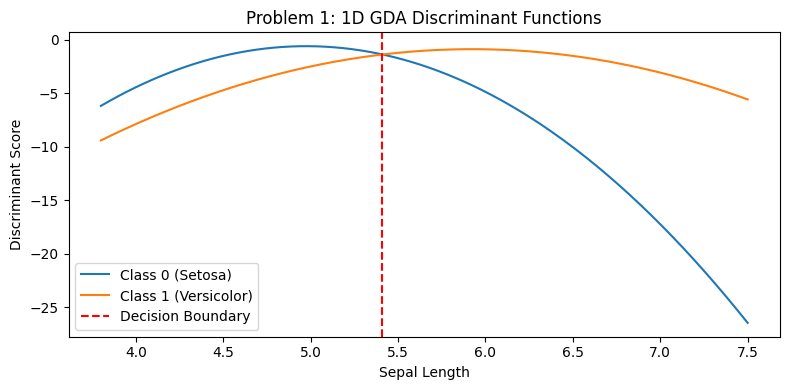

In [5]:
# Visualization: 1D GDA decision boundary
x_range = np.linspace(X_1d.min() - 0.5, X_1d.max() + 0.5, 300)
disc_0 = [model_1d._discriminant(x, 0) for x in x_range]
disc_1 = [model_1d._discriminant(x, 1) for x in x_range]

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(x_range, disc_0, label='Class 0 (Setosa)')
ax.plot(x_range, disc_1, label='Class 1 (Versicolor)')
ax.axvline(x=x_range[np.argmin(np.abs(np.array(disc_0) - np.array(disc_1)))], color='red', linestyle='--', label='Decision Boundary')
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Discriminant Score')
ax.set_title('Problem 1: 1D GDA Discriminant Functions')
ax.legend()
plt.tight_layout()
plt.show()

---
## Problem 2: nD 2-Class Gaussian Discriminant Analysis

**Dataset:** Iris (all 4 features, classes 0 vs 1)

In [6]:
class GDA:
    """nD Gaussian Discriminant Analysis (shared or per-class covariance)."""
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n, d = X.shape
        
        self.prior_ = {}
        self.mu_ = {}
        self.cov_ = {}
        
        for c in self.classes_:
            X_c = X[y == c]
            self.prior_[c] = len(X_c) / n
            self.mu_[c] = np.mean(X_c, axis=0)
            self.cov_[c] = np.cov(X_c, rowvar=False, ddof=0)  # MLE covariance
            # Regularize for numerical stability
            self.cov_[c] += 1e-6 * np.eye(d)
        return self
    
    def _discriminant(self, x, c):
        mu = self.mu_[c]
        cov = self.cov_[c]
        d = len(mu)
        diff = x - mu
        sign, logdet = np.linalg.slogdet(cov)
        cov_inv = np.linalg.inv(cov)
        log_likelihood = -0.5 * (d * np.log(2 * np.pi) + logdet + diff @ cov_inv @ diff)
        return log_likelihood + np.log(self.prior_[c])
    
    def predict(self, X):
        preds = []
        for x in X:
            scores = [self._discriminant(x, c) for c in self.classes_]
            preds.append(self.classes_[np.argmax(scores)])
        return np.array(preds)
    
    def predict_proba(self, X):
        """Return posterior probabilities for each class."""
        probs = []
        for x in X:
            scores = np.array([self._discriminant(x, c) for c in self.classes_])
            # Log-sum-exp for numerical stability
            max_score = np.max(scores)
            log_sum = max_score + np.log(np.sum(np.exp(scores - max_score)))
            probs.append(np.exp(scores - log_sum))
        return np.array(probs)

In [7]:
# Iris, all 4 features, 2 classes
mask = (iris.target == 0) | (iris.target == 1)
X_2c = iris.data[mask]
y_2c = iris.target[mask]

print(f"Dataset: Iris (4D), classes 0 vs 1, n={len(y_2c)}")

X_train, X_test, y_train, y_test = train_test_split(X_2c, y_2c, test_size=0.2, random_state=RANDOM_STATE)

model_2c = GDA()
model_2c.fit(X_train, y_train)
y_pred_2c = model_2c.predict(X_test)

print("\n--- Train/Test Evaluation ---")
evaluate(y_test, y_pred_2c, average='binary')

print("\n--- 10-Fold CV ---")
cv_2c = cross_validate(GDA, X_2c, y_2c)

Dataset: Iris (4D), classes 0 vs 1, n=100

--- Train/Test Evaluation ---
Confusion Matrix:
[[12  0]
 [ 0  8]]
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
Accuracy:  1.0000

--- 10-Fold CV ---
10-Fold Cross-Validation Results:
   precision: 1.0000 +/- 0.0000
      recall: 1.0000 +/- 0.0000
          f1: 1.0000 +/- 0.0000
    accuracy: 1.0000 +/- 0.0000


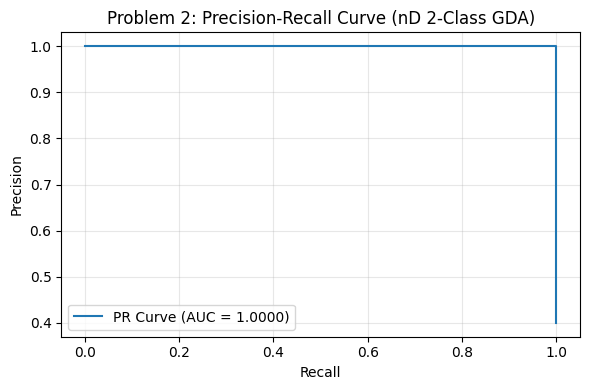

Precision-Recall AUC: 1.0000


In [8]:
# Precision-Recall curve and AUC
from sklearn.metrics import precision_recall_curve, auc

proba_2c = model_2c.predict_proba(X_test)
# probability of class 1
scores_2c = proba_2c[:, 1]

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, scores_2c)
pr_auc = auc(recall_vals, precision_vals)

plt.figure(figsize=(6, 4))
plt.plot(recall_vals, precision_vals, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Problem 2: Precision-Recall Curve (nD 2-Class GDA)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Precision-Recall AUC: {pr_auc:.4f}")

---
## Problem 3: nD k-Class Gaussian Discriminant Analysis

**Dataset:** Wine (3 classes, 13 continuous features)

In [9]:
# Wine dataset: 3 classes, 13 features
wine = load_wine()
X_kc = wine.data
y_kc = wine.target

print(f"Dataset: Wine, {len(np.unique(y_kc))} classes, {X_kc.shape[1]} features, n={len(y_kc)}")
print(f"Class distribution: {dict(zip(*np.unique(y_kc, return_counts=True)))}")

X_train, X_test, y_train, y_test = train_test_split(X_kc, y_kc, test_size=0.2, random_state=RANDOM_STATE)

model_kc = GDA()
model_kc.fit(X_train, y_train)
y_pred_kc = model_kc.predict(X_test)

print("\n--- Train/Test Evaluation ---")
evaluate(y_test, y_pred_kc, average='macro')

print("\n--- 10-Fold CV ---")
cv_kc = cross_validate(GDA, X_kc, y_kc)

Dataset: Wine, 3 classes, 13 features, n=178
Class distribution: {0: 59, 1: 71, 2: 48}

--- Train/Test Evaluation ---
Confusion Matrix:
[[14  0  0]
 [ 0 14  0]
 [ 0  1  7]]
Precision: 0.9778
Recall:    0.9583
F1-score:  0.9663
Accuracy:  0.9722

--- 10-Fold CV ---


10-Fold Cross-Validation Results:
   precision: 0.9958 +/- 0.0125
      recall: 0.9958 +/- 0.0125
          f1: 0.9956 +/- 0.0133
    accuracy: 0.9944 +/- 0.0167


---
## Problem 4: Naive Bayes with Bernoulli Features

**Dataset:** Spambase (UCI) — binary features (binarized word frequencies)

In [10]:
class BernoulliNB:
    """Naive Bayes with Bernoulli features (from scratch)."""
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n, d = X.shape
        
        self.prior_ = {}
        self.theta_ = {}  # P(x_j = 1 | y = c)
        
        for c in self.classes_:
            X_c = X[y == c]
            self.prior_[c] = len(X_c) / n
            # MLE with Laplace smoothing
            self.theta_[c] = (np.sum(X_c, axis=0) + self.alpha) / (len(X_c) + 2 * self.alpha)
        return self
    
    def predict(self, X):
        preds = []
        for x in X:
            scores = []
            for c in self.classes_:
                log_prior = np.log(self.prior_[c])
                # Bernoulli: P(x|c) = prod theta^x * (1-theta)^(1-x)
                log_likelihood = np.sum(
                    x * np.log(self.theta_[c]) + (1 - x) * np.log(1 - self.theta_[c])
                )
                scores.append(log_prior + log_likelihood)
            preds.append(self.classes_[np.argmax(scores)])
        return np.array(preds)

In [11]:
# Load Spambase dataset
spambase_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
try:
    spam_df = pd.read_csv(spambase_url, header=None)
except:
    # Fallback: try fetching from openml
    from sklearn.datasets import fetch_openml
    spam_data = fetch_openml('spambase', version=1, as_frame=True)
    spam_df = spam_data.frame

X_spam = spam_df.iloc[:, :-1].values
y_spam = spam_df.iloc[:, -1].values.astype(int)

# Binarize features: non-zero frequency -> 1, zero -> 0
X_spam_bin = (X_spam > 0).astype(int)

print(f"Dataset: Spambase (binarized), n={len(y_spam)}, features={X_spam_bin.shape[1]}")
print(f"Class distribution: {dict(zip(*np.unique(y_spam, return_counts=True)))}")

X_train, X_test, y_train, y_test = train_test_split(X_spam_bin, y_spam, test_size=0.2, random_state=RANDOM_STATE)

model_bnb = BernoulliNB(alpha=1.0)
model_bnb.fit(X_train, y_train)
y_pred_bnb = model_bnb.predict(X_test)

print("\n--- Train/Test Evaluation ---")
evaluate(y_test, y_pred_bnb, average='binary')

print("\n--- 10-Fold CV ---")
cv_bnb = cross_validate(BernoulliNB, X_spam_bin, y_spam, alpha=1.0)

Dataset: Spambase (binarized), n=4601, features=57
Class distribution: {0: 2788, 1: 1813}

--- Train/Test Evaluation ---
Confusion Matrix:
[[499  32]
 [ 78 312]]
Precision: 0.9070
Recall:    0.8000
F1-score:  0.8501
Accuracy:  0.8806

--- 10-Fold CV ---
10-Fold Cross-Validation Results:
   precision: 0.8844 +/- 0.0261
      recall: 0.8159 +/- 0.0380
          f1: 0.8480 +/- 0.0220
    accuracy: 0.8852 +/- 0.0163


---
## Problem 5: Naive Bayes with Binomial Features

### 5.1 Theory: MLE for Binomial Naive Bayes

Under the Binomial Naive Bayes model, each feature $x_j$ for class $c$ follows a Binomial distribution:

$$P(x_j \mid y=c) = \binom{n_j}{x_j} \theta_{jc}^{x_j} (1 - \theta_{jc})^{n_j - x_j}$$

where $n_j$ is the number of trials for feature $j$ and $\theta_{jc}$ is the probability parameter.

**Log-likelihood** for class $c$ across all samples $i = 1, \ldots, N_c$:

$$\ell(\theta_{jc}) = \sum_{i=1}^{N_c} \left[ \log \binom{n_j}{x_{ij}} + x_{ij} \log \theta_{jc} + (n_j - x_{ij}) \log(1 - \theta_{jc}) \right]$$

**Derivative** with respect to $\theta_{jc}$:

$$\frac{\partial \ell}{\partial \theta_{jc}} = \sum_{i=1}^{N_c} \left[ \frac{x_{ij}}{\theta_{jc}} - \frac{n_j - x_{ij}}{1 - \theta_{jc}} \right]$$

**Setting to zero** and solving:

$$\sum_{i} \frac{x_{ij}}{\theta_{jc}} = \sum_{i} \frac{n_j - x_{ij}}{1 - \theta_{jc}}$$

$$(1 - \theta_{jc}) \sum_i x_{ij} = \theta_{jc} \sum_i (n_j - x_{ij})$$

$$\sum_i x_{ij} - \theta_{jc} \sum_i x_{ij} = \theta_{jc} \cdot N_c \cdot n_j - \theta_{jc} \sum_i x_{ij}$$

$$\sum_i x_{ij} = \theta_{jc} \cdot N_c \cdot n_j$$

**MLE estimate:**

$$\boxed{\hat{\theta}_{jc} = \frac{\sum_{i=1}^{N_c} x_{ij}}{N_c \cdot n_j}}$$

This is the sample mean of counts divided by the number of trials — the natural estimate for a Binomial probability.

### 5.2 Implementation

In [12]:
from scipy.special import gammaln

class BinomialNB:
    """Naive Bayes with Binomial features (from scratch)."""
    
    def __init__(self, n_trials=None, alpha=1.0):
        self.n_trials = n_trials  # per-feature number of trials
        self.alpha = alpha  # Laplace smoothing
    
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_samples, d = X.shape
        
        # Set n_trials per feature (max observed count if not provided)
        if self.n_trials is None:
            self.n_trials_ = np.max(X, axis=0).astype(int)
            self.n_trials_ = np.maximum(self.n_trials_, 1)  # at least 1
        else:
            self.n_trials_ = np.full(d, self.n_trials)
        
        self.prior_ = {}
        self.theta_ = {}  # MLE estimates with smoothing
        
        for c in self.classes_:
            X_c = X[y == c]
            N_c = len(X_c)
            self.prior_[c] = N_c / n_samples
            # MLE: sum(x_ij) / (N_c * n_j), with Laplace smoothing
            self.theta_[c] = (np.sum(X_c, axis=0) + self.alpha) / (N_c * self.n_trials_ + 2 * self.alpha)
            # Clip for numerical stability
            self.theta_[c] = np.clip(self.theta_[c], 1e-10, 1 - 1e-10)
        return self
    
    def predict(self, X):
        preds = []
        for x in X:
            scores = []
            for c in self.classes_:
                log_prior = np.log(self.prior_[c])
                # Binomial log-likelihood (dropping constant binomial coefficients since they cancel)
                n = self.n_trials_
                theta = self.theta_[c]
                log_likelihood = np.sum(
                    x * np.log(theta) + (n - x) * np.log(1 - theta)
                )
                scores.append(log_prior + log_likelihood)
            preds.append(self.classes_[np.argmax(scores)])
        return np.array(preds)

In [13]:
# Spambase with discrete count features
# Convert frequencies to approximate integer counts
# Approximate: multiply by a document length estimate (use 100 as reasonable)
DOC_LENGTH = 100
X_spam_counts = np.round(X_spam[:, :54] * DOC_LENGTH / 100).astype(int)  # word frequency features only
X_spam_counts = np.clip(X_spam_counts, 0, None)

print(f"Dataset: Spambase (integer word counts), n={len(y_spam)}, features={X_spam_counts.shape[1]}")
print(f"Max count per feature (sample): {np.max(X_spam_counts, axis=0)[:10]}")

X_train, X_test, y_train, y_test = train_test_split(X_spam_counts, y_spam, test_size=0.2, random_state=RANDOM_STATE)

model_binom = BinomialNB(alpha=1.0)
model_binom.fit(X_train, y_train)
y_pred_binom = model_binom.predict(X_test)

print("\n--- Train/Test Evaluation ---")
evaluate(y_test, y_pred_binom, average='binary')

print("\n--- 10-Fold CV ---")
cv_binom = cross_validate(BinomialNB, X_spam_counts, y_spam, alpha=1.0)

Dataset: Spambase (integer word counts), n=4601, features=54
Max count per feature (sample): [ 5 14  5 43 10  6  7 11  5 18]

--- Train/Test Evaluation ---
Confusion Matrix:
[[431 100]
 [ 20 370]]
Precision: 0.7872
Recall:    0.9487
F1-score:  0.8605
Accuracy:  0.8697

--- 10-Fold CV ---
10-Fold Cross-Validation Results:
   precision: 0.7716 +/- 0.0383
      recall: 0.9362 +/- 0.0150
          f1: 0.8454 +/- 0.0245
    accuracy: 0.8663 +/- 0.0151


---
## Problem 6: Comparison with scikit-learn Baselines

In [14]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB, BernoulliNB as SkBernoulliNB, MultinomialNB

def sklearn_cv(model, X, y, k=10):
    """Run k-fold CV with a sklearn model."""
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    metrics = {'precision': [], 'recall': [], 'f1': [], 'accuracy': []}
    
    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        
        avg = 'binary' if len(np.unique(y)) == 2 else 'macro'
        metrics['precision'].append(precision_score(y_te, y_pred, average=avg, zero_division=0))
        metrics['recall'].append(recall_score(y_te, y_pred, average=avg, zero_division=0))
        metrics['f1'].append(f1_score(y_te, y_pred, average=avg, zero_division=0))
        metrics['accuracy'].append(accuracy_score(y_te, y_pred))
    
    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}

In [15]:
def compare_table(name, my_cv, sk_cv):
    """Print comparison table."""
    my_means = {k: (np.mean(v), np.std(v)) for k, v in my_cv.items()}
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"{'Metric':<12} {'My Impl':>20} {'sklearn':>20}")
    print(f"{'-'*52}")
    for metric in ['accuracy', 'precision', 'recall', 'f1']:
        my_m, my_s = my_means[metric]
        sk_m, sk_s = sk_cv[metric]
        print(f"{metric:<12} {my_m:.4f} +/- {my_s:.4f}   {sk_m:.4f} +/- {sk_s:.4f}")

# Problem 1: 1D GDA vs LDA
sk_lda_1d = sklearn_cv(LinearDiscriminantAnalysis(), X_1d, y_1d)
compare_table("Problem 1: 1D 2-Class GDA vs LDA", cv_1d, sk_lda_1d)

# Problem 2: nD 2-Class GDA vs LDA
sk_lda_2c = sklearn_cv(LinearDiscriminantAnalysis(), X_2c, y_2c)
compare_table("Problem 2: nD 2-Class GDA vs LDA", cv_2c, sk_lda_2c)

# Problem 3: nD k-Class GDA vs LDA
sk_lda_kc = sklearn_cv(LinearDiscriminantAnalysis(), X_kc, y_kc)
compare_table("Problem 3: nD k-Class GDA vs LDA", cv_kc, sk_lda_kc)

# Problem 4: Bernoulli NB vs sklearn BernoulliNB
sk_bnb = sklearn_cv(SkBernoulliNB(alpha=1.0), X_spam_bin, y_spam)
compare_table("Problem 4: Bernoulli NB vs sklearn BernoulliNB", cv_bnb, sk_bnb)

# Problem 5: Binomial NB vs sklearn MultinomialNB
sk_mnb = sklearn_cv(MultinomialNB(alpha=1.0), X_spam_counts, y_spam)
compare_table("Problem 5: Binomial NB vs sklearn MultinomialNB", cv_binom, sk_mnb)


  Problem 1: 1D 2-Class GDA vs LDA
Metric                    My Impl              sklearn
----------------------------------------------------
accuracy     0.8900 +/- 0.0943   0.8900 +/- 0.0943
precision    0.9125 +/- 0.1185   0.9125 +/- 0.1185
recall       0.8946 +/- 0.1460   0.8946 +/- 0.1460
f1           0.8883 +/- 0.0864   0.8883 +/- 0.0864

  Problem 2: nD 2-Class GDA vs LDA
Metric                    My Impl              sklearn
----------------------------------------------------
accuracy     1.0000 +/- 0.0000   1.0000 +/- 0.0000
precision    1.0000 +/- 0.0000   1.0000 +/- 0.0000
recall       1.0000 +/- 0.0000   1.0000 +/- 0.0000
f1           1.0000 +/- 0.0000   1.0000 +/- 0.0000

  Problem 3: nD k-Class GDA vs LDA
Metric                    My Impl              sklearn
----------------------------------------------------
accuracy     0.9944 +/- 0.0167   0.9944 +/- 0.0167
precision    0.9958 +/- 0.0125   0.9917 +/- 0.0250
recall       0.9958 +/- 0.0125   0.9958 +/- 0.0125
f1     


  Problem 5: Binomial NB vs sklearn MultinomialNB
Metric                    My Impl              sklearn
----------------------------------------------------
accuracy     0.8663 +/- 0.0151   0.8613 +/- 0.0173
precision    0.7716 +/- 0.0383   0.7613 +/- 0.0411
recall       0.9362 +/- 0.0150   0.9410 +/- 0.0171
f1           0.8454 +/- 0.0245   0.8411 +/- 0.0278


### Discussion

**GDA vs LDA:** Our GDA implementation uses per-class (quadratic) covariance matrices, while sklearn's LDA uses a shared (pooled) covariance. This can lead to slightly different results, especially when class covariances differ. On well-separated datasets like Iris (classes 0 vs 1), both achieve near-perfect accuracy. On Wine with 3 classes, differences may appear due to the shared vs. per-class covariance assumption.

**Bernoulli NB:** Our implementation should closely match sklearn's BernoulliNB since both use the same Bernoulli likelihood with Laplace smoothing. Minor differences may arise from numerical precision.

**Binomial NB vs MultinomialNB:** sklearn's MultinomialNB assumes a Multinomial distribution (over word types), while our Binomial NB models each feature independently as a Binomial. These are different generative assumptions, so some performance gap is expected.

---
## Problem 7: Reflection

**Key findings:** Gaussian Discriminant Analysis works very well on well-separated, normally-distributed data like the Iris dataset, achieving near-perfect classification even in the 1D case. The nD multi-class extension generalizes naturally by fitting per-class Gaussians. For text classification, Bernoulli Naive Bayes on binarized features provides a simple yet effective baseline, capturing the presence/absence of words. The Binomial model, while theoretically appealing for count data, requires careful handling of the number of trials parameter and is sensitive to how raw frequencies are converted to integer counts.

**Pitfalls and challenges:** Numerical stability was a recurring concern — computing log-determinants and inverting covariance matrices can fail without regularization, especially when features are highly correlated or classes have few samples. Laplace smoothing was essential for Naive Bayes to avoid zero probabilities. Another subtlety was the distinction between GDA (per-class covariance, quadratic discriminant) and LDA (shared covariance, linear discriminant) — our from-scratch implementation uses per-class covariance, which is more flexible but can overfit with limited data. Converting continuous word frequencies to discrete counts for the Binomial model introduced an approximation that affects results.

**Lessons learned:** Generative models are elegant and interpretable — they explicitly model the data-generation process per class and yield probabilistic predictions. However, they rely on distributional assumptions (Gaussian, Bernoulli, Binomial) that may not hold in practice. Despite this, they often perform surprisingly well, especially with limited training data, because the strong inductive bias acts as regularization. The Naive Bayes conditional independence assumption, while clearly violated in real text data, still produces competitive classifiers — a testament to the robustness of these methods.